In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

Matplotlib is building the font cache; this may take a moment.


In [ ]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.shape

(1470, 35)

**Exploratory Data Analysis**

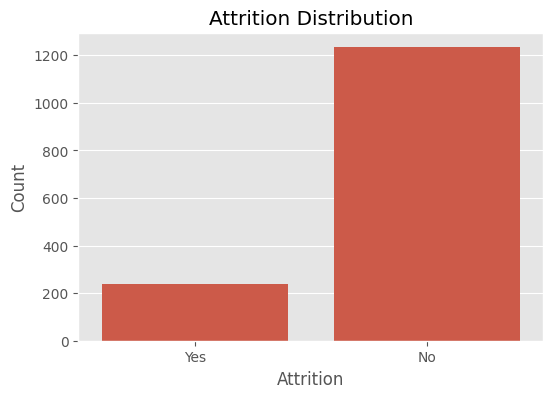

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)

plt.title('Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Count')

plt.show()

#distribusi data Target Attrition untuk melihat jumlah resign vs tidak resign

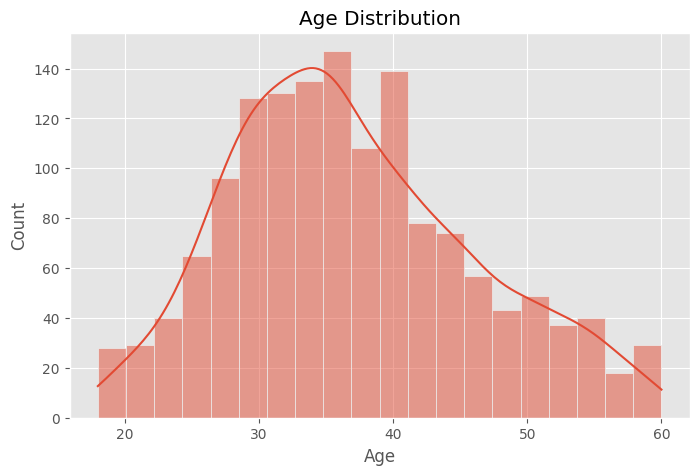

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')

plt.show()

#distribusi data umur

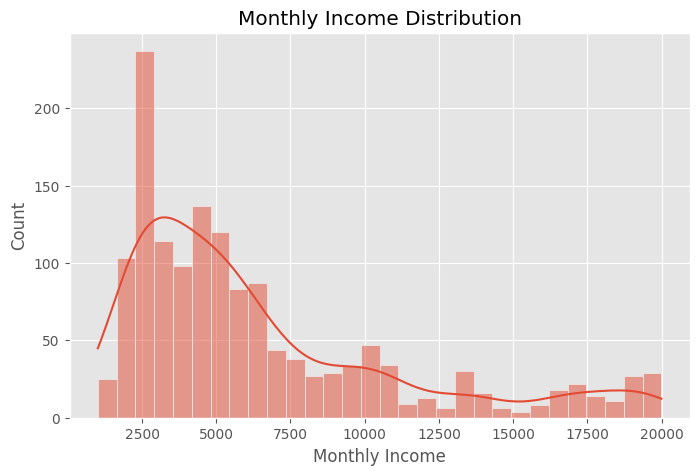

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyIncome'], bins=30, kde=True)

plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income')

plt.show()

#distribusi data monthly income

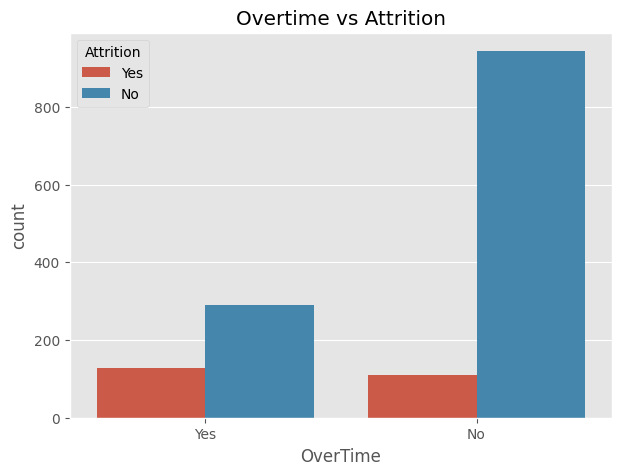

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x='OverTime', hue='Attrition', data=df)

plt.title('Overtime vs Attrition')

plt.show()

#distribusi data untuk overtime vs attrition


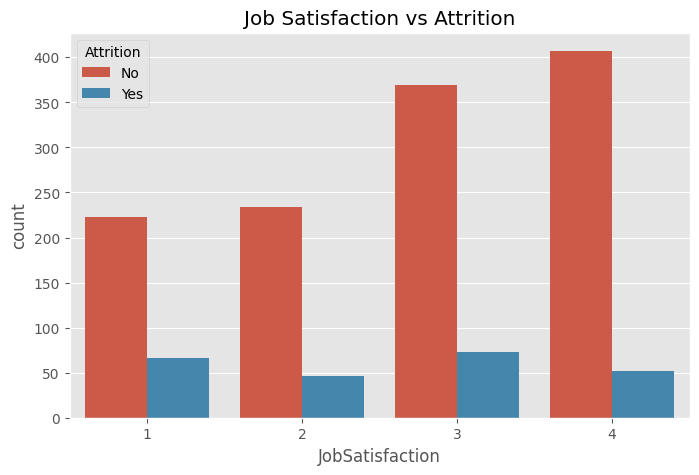

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)

plt.title('Job Satisfaction vs Attrition')

plt.show()

#distribusi data untuk lihat kepuasan kerja employee

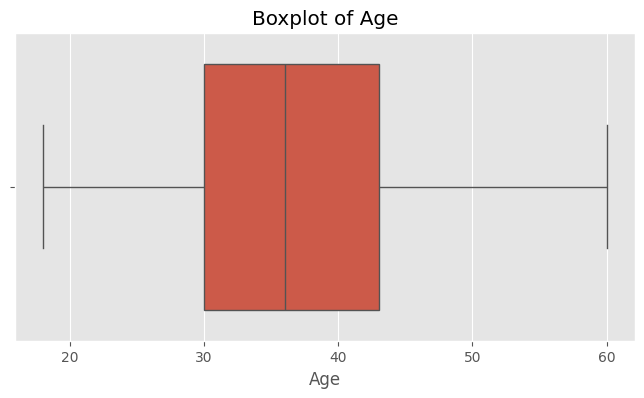

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Age'])

plt.title('Boxplot of Age')

plt.show()

#outlier age

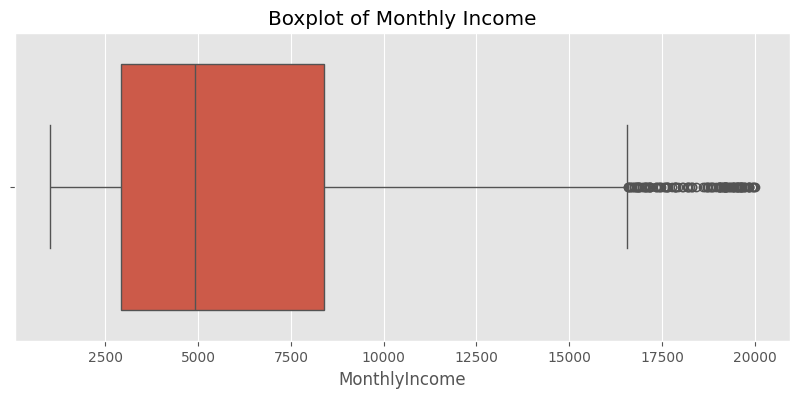

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df['MonthlyIncome'])

plt.title('Boxplot of Monthly Income')

plt.show()

#outlier monthly income
#yg titik-titik itu: ada employee dengan salary jauh lebih tinggi dibanding mayoritas employee lain.

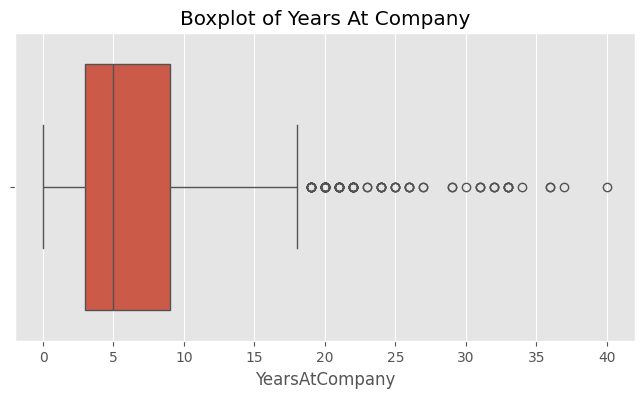

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['YearsAtCompany'])

plt.title('Boxplot of Years At Company')

plt.show()

#outlier years at company

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
#correlation

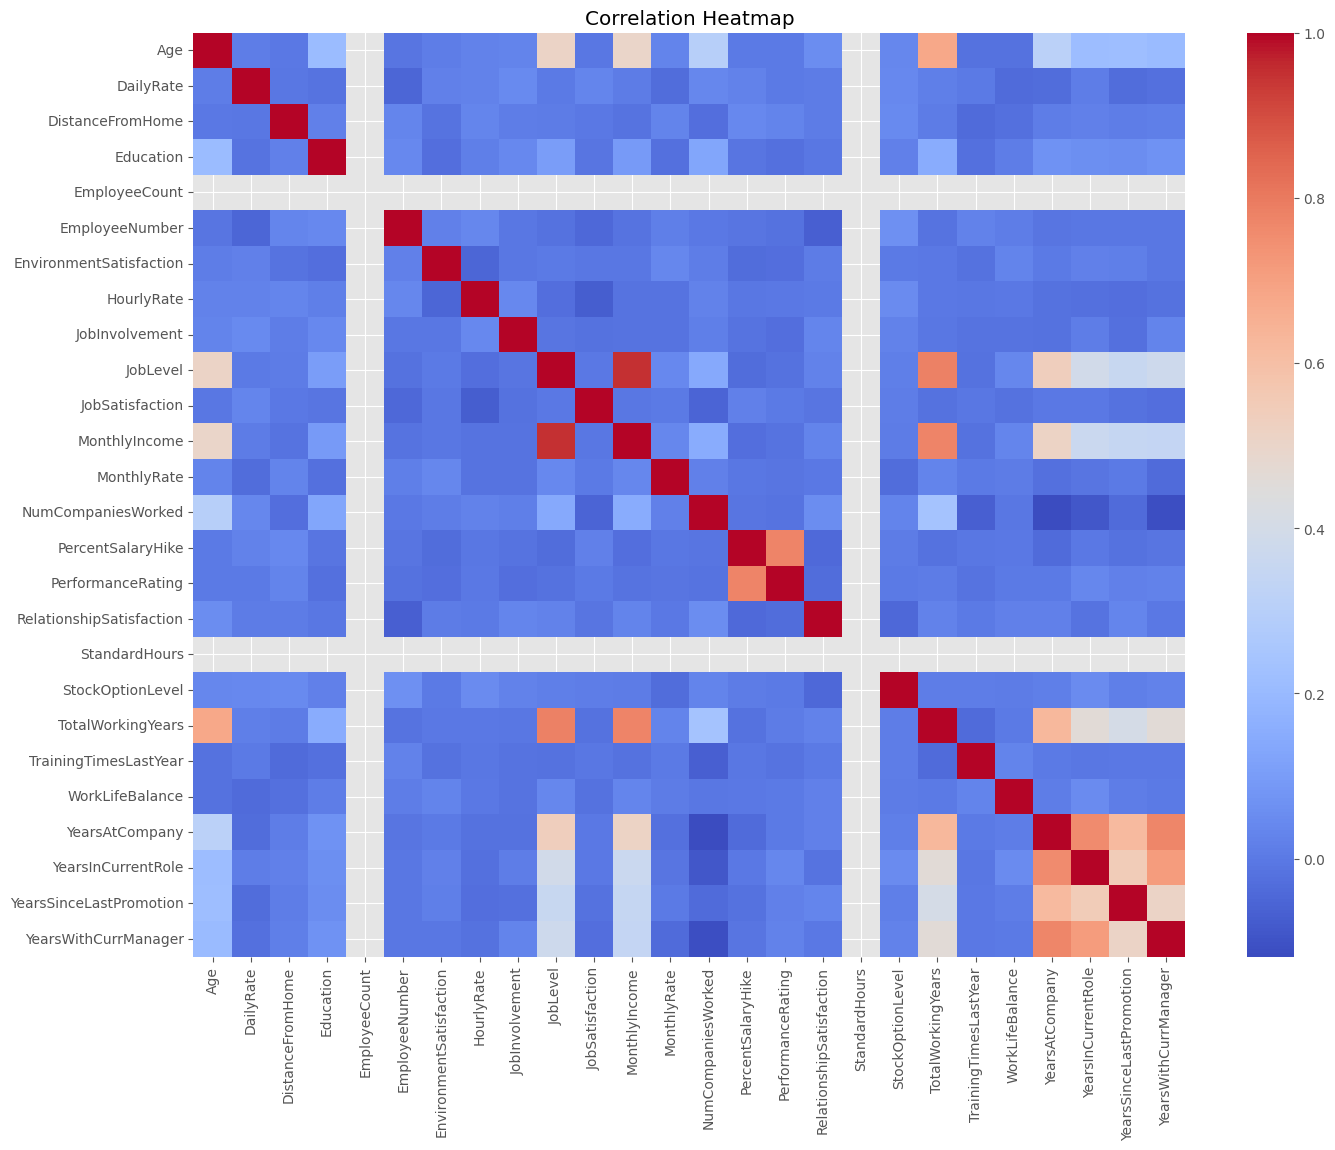

In [ ]:
plt.figure(figsize=(16,12))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
df['Attrition'].value_counts(normalize=True)*100

#imbalance analysis bagian Persentase Attrition

,proportion
Attrition,
No,83.877551
Yes,16.122449


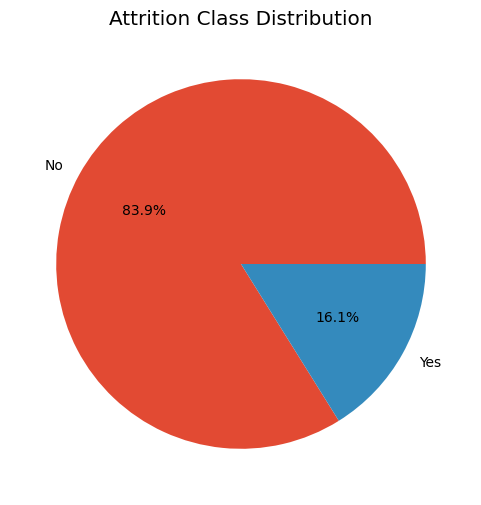

In [ ]:
attrition_counts = df['Attrition'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    attrition_counts,
    labels=attrition_counts.index,
    autopct='%1.1f%%'
)

plt.title('Attrition Class Distribution')

plt.show()

#imbalance analysis bagian Visualisasi imbalance

**KESIMPULAN EDA**
- Dataset memiliki 1470 data dan 35 fitur
- Tidak terdapat missing value
- Distribusi attrition menunjukkan sedikit imbalance
- Overtime memiliki hubungan dengan attrition
- Terdapat beberapa outlier pada MonthlyIncome
- Korelasi antar fitur numerik relatif normal

**DATA PREPROCESSING**

1. Imputation

In [ ]:
df.isnull().sum() #cek missing value (hasilnya engga ada yang missing)

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


2. ENCODING

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
df_encoded = df.copy()

In [ ]:
le = LabelEncoder()

for column in df_encoded.columns:
    if df_encoded[column].dtype == 'object':
        df_encoded[column] = le.fit_transform(df_encoded[column])

#ENCODING SEMUA KOLOM OBJECT

In [ ]:
df_encoded.head() #UNTUK CEK HASIL

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


3. FEATURE SELECTION

In [ ]:
df_encoded = df_encoded.drop([
    'EmployeeCount',
    'EmployeeNumber',
    'StandardHours',
    'Over18'
], axis=1)

#dilakukan untuk drop fitur tidak penting

In [ ]:
X = df_encoded.drop('Attrition', axis=1)

y = df_encoded['Attrition']

#memisahkan fitur dan target

PENJELASAN

X
berisi:
Age, MonthlyIncome, JobRole, dll.

y
berisi:
Attrition, Target prediksi.

4. SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

HASIL
Data berubah menjadi:
skala standar
mean ≈ 0
std ≈ 1

5. CEK SHAPE DATA FINAL

In [ ]:
X_scaled.shape

(1470, 30)

**MODEL BUILDING**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

1. TRAIN-TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

#CEK UKURAN DATA

X_train shape : (1176, 30)
X_test shape  : (294, 30)
y_train shape : (1176,)
y_test shape  : (294,)


2. MODEL TRAINING

In [ ]:
#MEMBUAT MODEL
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
#TRAINING MODEL
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#PREDICTION
lr_pred = lr_model.predict(X_test)

dt_pred = dt_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

In [ ]:
#EVALUATION METRICS
#Logistic Regression
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_roc_auc = roc_auc_score(y_test, lr_pred)

In [ ]:
#EVALUATION METRICS
#Decision Tree
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test, dt_pred)

In [ ]:
#EVALUATION METRICS
#Decision Tree
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_pred)

In [ ]:
#TABEL PERBANDINGAN
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    'Precision': [
        lr_precision,
        dt_precision,
        rf_precision
    ],

    'Recall': [
        lr_recall,
        dt_recall,
        rf_recall
    ],

    'F1-Score': [
        lr_f1,
        dt_f1,
        rf_f1
    ],

    'ROC-AUC': [
        lr_roc_auc,
        dt_roc_auc,
        rf_roc_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.894558,0.700000,0.358974,0.474576,0.667722
1,Decision Tree,0.799320,0.236842,0.230769,0.233766,0.558522
2,Random Forest,0.870748,0.600000,0.076923,0.136364,0.534540


In [ ]:
import joblib

In [ ]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
joblib.dump(lr_model, 'model.pkl')


['model.pkl']

In [ ]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']